In [ ]:
import torch
if torch.cuda.is_available():
    print("gpu available")
    print(torch.cuda.get_device_name(0))
else:
    print("no gpu available")

gpu available
NVIDIA A100-SXM4-80GB


In [ ]:
!pip install wfdb # ignore error message relating to dependency conflict (cant seem to fix, doesn't seem to affect program?)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 127.4 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have 

In [ ]:
import wfdb #load ecg data from physionet
import numpy as np # numerical operations
import matplotlib.pyplot as plt # plotting
import torch # build model
import torch.nn as nn # neural network, defines layers and structure of model
import torch.optim as optim # optimizers used to adjust model weights
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader # batch data during training + eval
from sklearn.model_selection import train_test_split # to split and evaluate data
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from google.colab import drive
import os
import joblib
import gc
import matplotlib.colors as mcolors
import seaborn as sns

In [ ]:
drive.mount('/content/drive')

#load the previous models
class GRUClassifier(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, dropout=0.3):
        super(GRUClassifier, self).__init__()
        self.gru = nn.GRU(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out, _ = self.gru(x)
        last_hidden = out[:,-1,:]
        last_hidden = self.dropout(last_hidden)
        out=self.fc(last_hidden)
        return self.sigmoid(out)

class SelfAttention(nn.Module):
    def __init__(self,hidden_dim):
        super(SelfAttention,self).__init__()
        self.attention = nn.Linear(hidden_dim,1)

    def forward(self,gru_output): #gru_output_shape: (batch, seq_len, hidden_dim)
        # calc attention scores for ea/ time step
        attn_scores = self.attention(gru_output) # (batch, seq_len, 1)
        attn_weights = F.softmax(attn_scores,dim=1)

        # apply attention weights
        context = torch.sum(attn_weights * gru_output, dim=1)

        return context,attn_weights

class GRUWithAttention(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, dropout=0.3):
        super(GRUWithAttention, self).__init__()

        # main gru
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # self attention layer
        self.attention = SelfAttention(hidden_dim)

        # fully connected layers
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self,x):
        # x shape: (batch, seq_len, input_dim)

        # gru forward pass (get outputs @ ALL time stamps)
        gru_out, _ = self.gru(x)

        # apply self-attention
        attended, attn_weights = self.attention(gru_out)

        # dropout
        attended = self.dropout(attended)

        # final classification
        out = self.fc(attended)

        return self.sigmoid(out)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # check if theres gpu

model = GRUWithAttention(dropout=0.3).to(device) # creates model on device (cpu/gpu)
criterion = nn.BCELoss()  # binary cross-entropy (bce) loss for binary classification
optimizer = optim.Adam(model.parameters(), lr=0.0005) # adam optimizer to update model weights in training


Mounted at /content/drive


In [ ]:
# model 1 architecture: normal vs abnormal (no layernorm)
class SelfAttention_Model1(nn.Module):
    def __init__(self, hidden_dim):
        super(SelfAttention_Model1, self).__init__()
        self.attention = nn.Linear(hidden_dim, 1)

    def forward(self, gru_output):
        attn_scores = self.attention(gru_output)
        attn_weights = F.softmax(attn_scores, dim=1)
        context = torch.sum(attn_weights * gru_output, dim=1)
        return context, attn_weights

class GRUWithAttention_Model1(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, dropout=0.3):
        super(GRUWithAttention_Model1, self).__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.attention = SelfAttention_Model1(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        gru_out, _ = self.gru(x)
        attended, attn_weights = self.attention(gru_out)
        attended = self.dropout(attended)
        out = self.fc(attended)
        return self.sigmoid(out)

# model 2 architecture: sva vs pre-sva (with layernorm)
class SelfAttention_Model2(nn.Module):
    def __init__(self, hidden_dim):
        super(SelfAttention_Model2, self).__init__()
        self.attention = nn.Linear(hidden_dim, 1)
        self.layer_norm = nn.LayerNorm(hidden_dim)  # uses layernorm here

    def forward(self, gru_output):
        gru_output = self.layer_norm(gru_output)  # uses layernorm here
        attn_scores = self.attention(gru_output)
        attn_weights = F.softmax(attn_scores, dim=1)
        context = torch.sum(attn_weights * gru_output, dim=1)
        return context, attn_weights

class GRUWithAttention_Model2(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, dropout=0.3):
        super(GRUWithAttention_Model2, self).__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.attention = SelfAttention_Model2(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        gru_out, _ = self.gru(x)
        attended, attn_weights = self.attention(gru_out)
        attended = self.dropout(attended)
        out = self.fc(attended)
        return self.sigmoid(out)

# load models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# model 1 (normal vs abnormal)
model1 = GRUWithAttention_Model1(dropout=0.3).to(device)
model1_path = '/content/drive/MyDrive/ZiyaAhmad/science/Synopsys 2025-2026/Code/best models/normal_vs_abnormal/0.9589|17:02|2026-02-19|'
model1.load_state_dict(torch.load(model1_path, map_location=device))
model1.eval()
print("model 1 (normal_vs_abnormal) loaded")

# model 2 (sva vs pre-sva)
model2 = GRUWithAttention_Model2(dropout=0.3).to(device)
model2_path = '/content/drive/MyDrive/ZiyaAhmad/science/Synopsys 2025-2026/Code/best models/sva_vs_presva/0.9717|15:08|2026-02-18|'
model2.load_state_dict(torch.load(model2_path, map_location=device))
model2.eval()
print("model 2 (sva_vs_presva) loaded")

print("\both models loaded successfully!")

Using device: cuda
Model 1 (normal_vs_abnormal) loaded
Model 2 (sva_vs_presva) loaded

Both models loaded successfully!
Model 1: GRU + Attention (no LayerNorm)
Model 2: GRU + Attention + LayerNorm


In [ ]:
save_path = '/content/drive/MyDrive/ZiyaAhmad/12sec_ecg_data.npz'

data = np.load(save_path)
all_windows = data['windows']
all_labels = data['labels']

print("loaded ecg data")
class_counts = np.bincount(all_labels)
print("Class distribution")
print(f"Normal: {class_counts[0]}, SVA: {class_counts[1]}, Pre-SVA: {class_counts[2]}")
all_windows = np.array(all_windows) # convert from lists to np arrays
all_labels = np.array(all_labels)

print("all_windows shape:", all_windows.shape) # .shape tells dimensions of the array
print("all_labels shape:", all_labels.shape) # prints one number b/c there's no 2nd dimension
# first number is # of windows (samples), second number is # of data points in windows

split_path = '/content/drive/MyDrive/ZiyaAhmad/12sec_train_test_split.npz'
split_data = np.load(split_path)
train_indices = split_data['train_indices']
test_indices = split_data['test_indices']

print("loaded train/test samples")
print(f"   Train samples: {len(train_indices):,}")
print(f"   Test samples: {len(test_indices):,}")

loaded ecg data
Class distribution
Normal: 145493, SVA: 78206, Pre-SVA: 22607
all_windows shape: (246306, 1536)
all_labels shape: (246306,)
loaded train/test samples
   Train samples: 197,044
   Test samples: 49,262


Test samples: 49,262
Label distribution:
  Normal (0): 29,099
  SVA (1): 15,641
  Pre-SVA (2): 4,522

AUROC ANALYSIS

Normal:
  AUROC: 0.9926

SVA:
  AUROC: 0.9848

Pre-SVA:
  AUROC: 0.9421

Macro-Average AUROC: 0.9732


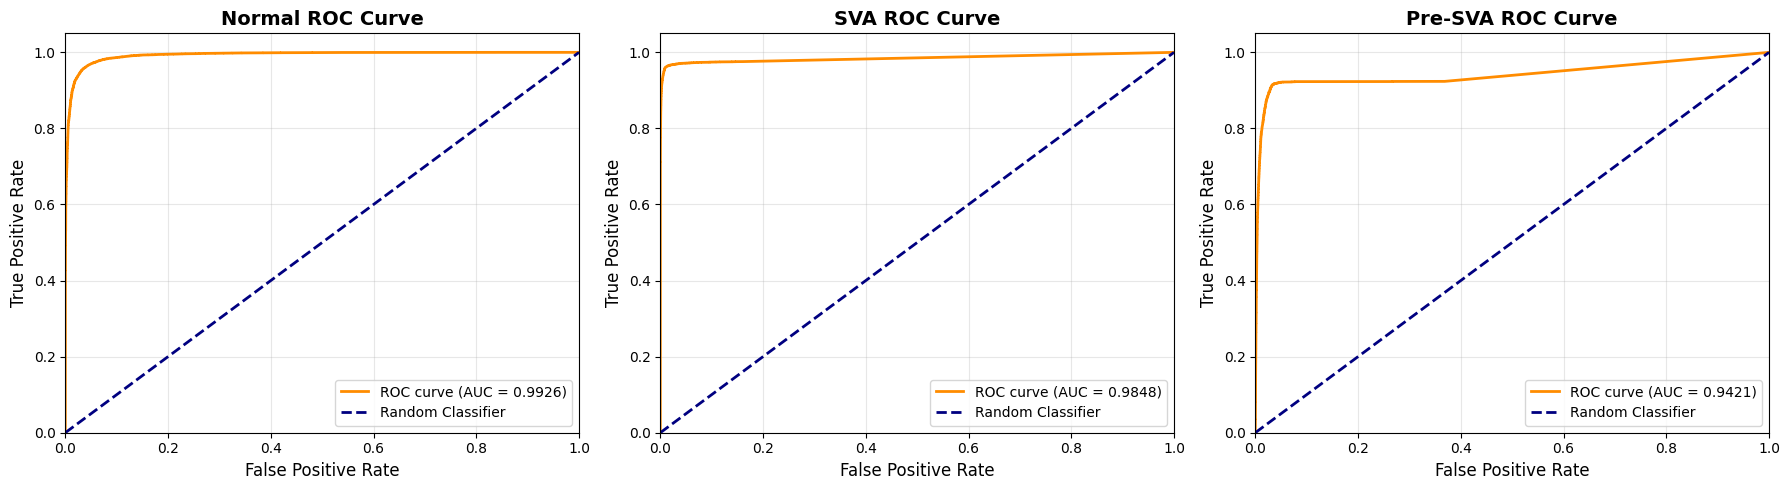

In [ ]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# create test loader w/ three class labels
all_labels_3class = data['labels']  # 0=Normal, 1=SVA, 2=Pre-SVA
test_indices_all = split_data['test_indices']

# get test data
test_windows = all_windows[test_indices_all]
test_labels_3class = all_labels_3class[test_indices_all]

# normalize (use same scaler as training)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
all_windows_flat = all_windows.reshape(-1, 1)
all_windows_scaled = scaler.fit_transform(all_windows_flat).reshape(all_windows.shape)

# get normalized test data
X_test = all_windows_scaled[test_indices_all]
y_test_3class = test_labels_3class

# convert to tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
y_test_3class_tensor = torch.tensor(y_test_3class, dtype=torch.long)

# create test dataset and loader
test_dataset = TensorDataset(X_test_tensor, y_test_3class_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Test samples: {len(X_test):,}")
print(f"Label distribution:")
print(f"  Normal (0): {np.sum(y_test_3class == 0):,}")
print(f"  SVA (1): {np.sum(y_test_3class == 1):,}")
print(f"  Pre-SVA (2): {np.sum(y_test_3class == 2):,}")

# running auroc code
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# set models to eval mode
model1.eval()
model2.eval()

all_true_labels = []
all_predicted_labels = []
all_class_probs = []

with torch.no_grad():
    for X_batch, y_batch_3class in test_loader:
        X_batch = X_batch.to(device)

        # model 1
        outputs_m1 = model1(X_batch).view(-1)
        prob_abnormal = outputs_m1.cpu().numpy()
        prob_normal = 1 - prob_abnormal

        predicted_m1 = (outputs_m1 > 0.5).float()

        # model 2: For samples predicted as abnormal
        abnormal_mask = predicted_m1 == 1

        # initialize final predictions
        final_predictions = torch.zeros(len(X_batch))
        final_predictions[~abnormal_mask.cpu()] = 0  # Normal

        # initialize probability matrix [normal, sva, presva]
        batch_probs = np.zeros((len(X_batch), 3))
        batch_probs[:, 0] = prob_normal

        if abnormal_mask.sum() > 0:
            X_abnormal = X_batch[abnormal_mask]

            # model 2
            outputs_m2 = model2(X_abnormal).view(-1)
            prob_presva = outputs_m2.cpu().numpy()
            prob_sva = 1 - prob_presva

            predicted_m2 = (outputs_m2 > 0.5).float()

            # map to 3-class
            final_predictions[abnormal_mask.cpu()] = predicted_m2.cpu() + 1

            # distribute probabilities
            abnormal_indices = np.where(abnormal_mask.cpu().numpy())[0]
            for idx, orig_idx in enumerate(abnormal_indices):
                p_abnormal = prob_abnormal[orig_idx]
                batch_probs[orig_idx, 1] = p_abnormal * prob_sva[idx]
                batch_probs[orig_idx, 2] = p_abnormal * prob_presva[idx]

        all_true_labels.extend(y_batch_3class.cpu().numpy())
        all_predicted_labels.extend(final_predictions.numpy())
        all_class_probs.extend(batch_probs)

# convert to arrays
all_true_labels = np.array(all_true_labels)
all_predicted_labels = np.array(all_predicted_labels)
all_class_probs = np.array(all_class_probs)

# calculate AUROC
print("\n" + "="*70)
print("AUROC ANALYSIS")
print("="*70)

class_names = ['Normal', 'SVA', 'Pre-SVA']
auroc_scores = {}

for i, class_name in enumerate(class_names):
    y_true_binary = (all_true_labels == i).astype(int)
    y_score = all_class_probs[:, i]

    auroc = roc_auc_score(y_true_binary, y_score)
    auroc_scores[class_name] = auroc

    print(f"\n{class_name}:")
    print(f"  AUROC: {auroc:.4f}")

macro_auroc = np.mean(list(auroc_scores.values()))
print(f"\nMacro-Average AUROC: {macro_auroc:.4f}")

# plot ROC curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (class_name, ax) in enumerate(zip(class_names, axes)):
    y_true_binary = (all_true_labels == i).astype(int)
    y_score = all_class_probs[:, i]

    fpr, tpr, thresholds = roc_curve(y_true_binary, y_score)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, color='darkorange', lw=2,
            label=f'ROC curve (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
            label='Random Classifier')

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'{class_name} ROC Curve', fontsize=14, fontweight='bold')
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)

In [ ]:
# load scalers -> change these paths to match your own
scaler_model1_path = '/content/drive/MyDrive/ZiyaAhmad/science/Synopsys 2025-2026/Code/best models/scaler_model1.pkl'
scaler_model2_path = '/content/drive/MyDrive/ZiyaAhmad/science/Synopsys 2025-2026/Code/chain model/scaler_model2.pkl'

scaler_model1 = joblib.load(scaler_model1_path)
scaler_model2 = joblib.load(scaler_model2_path)

# model 1 normalization
all_windows_flat = all_windows.reshape(-1, 1)
all_windows_scaled_m1 = scaler_model1.transform(all_windows_flat).reshape(all_windows.shape)

X_m1 = torch.tensor(all_windows_scaled_m1, dtype=torch.float32).unsqueeze(-1)
del all_windows_scaled_m1, all_windows_flat
gc.collect()

# use the loaded indices
X_test_m1 = X_m1[test_indices]
del X_m1
gc.collect()

# model 2 normalization
all_windows_flat = all_windows.reshape(-1, 1)
all_windows_scaled_m2 = scaler_model2.transform(all_windows_flat).reshape(all_windows.shape)

X_m2 = torch.tensor(all_windows_scaled_m2, dtype=torch.float32).unsqueeze(-1)
del all_windows_scaled_m2, all_windows_flat
gc.collect()

# use the loaded indices
X_test_m2 = X_m2[test_indices]
y_test = torch.tensor(all_labels[test_indices], dtype=torch.float32)
del X_m2
gc.collect()

print(f"\test set breakdown:")
print(f"  normal: {np.sum(all_labels[test_indices] == 0):,}")
print(f"  sva: {np.sum(all_labels[test_indices] == 1):,}")
print(f"  pre-sva: {np.sum(all_labels[test_indices] == 2):,}")


Test set breakdown:
  Normal: 29,099
  SVA: 15,641
  Pre-SVA: 4,522


In [ ]:
def chain_predict(idx, model1, model2, device, presva_threshold=0.5, model1_threshold=0.5):
    # chain prediction: normal -> (if abnormal) -> sva or presva
    # args:
    #   ecg_window = single ecg window, shape (1, 1024, 1) or (1024, 1)
    #   model1: normal_vs_abnormal
    #   model2: sva_vs_presva
    #   device: torch device
    # returns:
    #   0 (normal), 1 (sva), 2 (presva)

    ecg_m1 = X_test_m1[idx:idx+1].to(device)

    with torch.no_grad():
        prob_abnormal = model1(ecg_m1).item()

        if prob_abnormal <= model1_threshold:
            return 0, {
                'prediction': 'normal',
                'model1_prob_abnormal': prob_abnormal,
                'confidence': 1 - prob_abnormal
            }

        ecg_m2 = X_test_m2[idx:idx+1].to(device)
        prob_presva = model2(ecg_m2).item()

        if (prob_presva) > presva_threshold:
            return 2, {
                'prediction': 'pre-sva',
                'model1_prob_abnormal': prob_abnormal,
                'model2_prob_presva': prob_presva,
                'confidence': prob_presva
            }
        else:
            return 1, {
                'prediction': 'sva',
                'model1_prob_abnormal':prob_abnormal,
                'model2_prob_presva':prob_presva,
                'confidence':1-prob_presva
            }

In [ ]:
# test on single sample
sample_idx = 1 # CHANGE TO OTHER SAMPLES
true_label = y_test[sample_idx].item()

label_names = ['normal', 'sva', 'pre-sva']
prediction, info = chain_predict(sample_idx, model1, model2, device)
print(f"true label: {int(true_label)} ({label_names[int(true_label)]})")
print(f"predicted: {prediction} ({info['prediction']})")
print(f"confidence: {info['confidence']:.4f}")
print(f"correct: {'yes' if prediction == true_label else 'no'}")

true label: 0 (normal)
predicted: 0 (normal)
confidence: 0.9702
correct: yes


confusion matrix


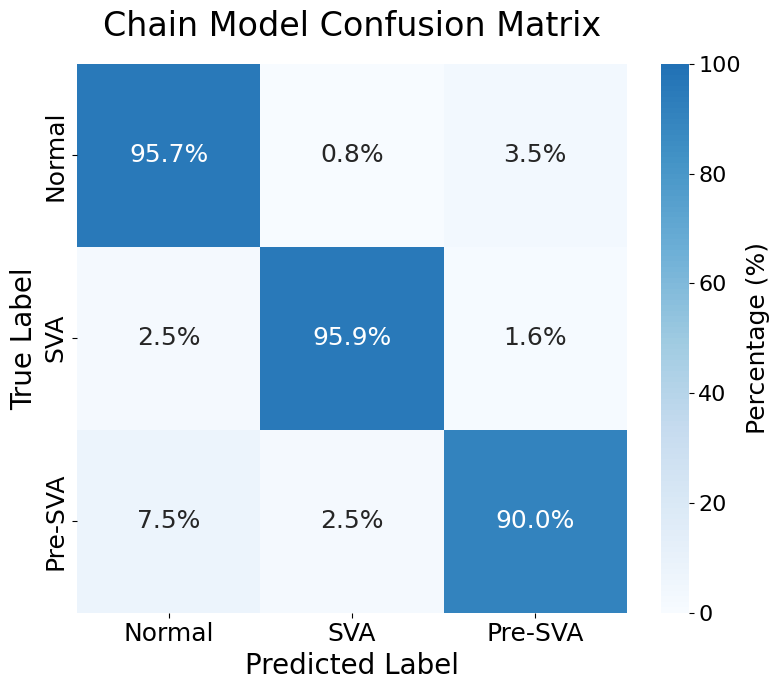


Confusion Matrix (numbers):
[[27857   225  1017]
 [  386 15001   254]
 [  340   111  4071]]

overall accuracy: 0.9526

classification report: 


In [ ]:
# evaluate on entire set

all_predictions = []

for i in range(len(X_test_m1)):
    prediction, _ = chain_predict(i,model1,model2,device)
    all_predictions.append(prediction)

all_predictions = np.array(all_predictions)
true_labels = y_test.numpy()

accuracy = accuracy_score(true_labels, all_predictions)

label_names = ['Normal', 'SVA', 'Pre-SVA']

print("confusion matrix")
fig, ax = plt.subplots(figsize=(8, 7))

# get confusion matrix
cm = confusion_matrix(true_labels, all_predictions)

# calculate percentages (row-wise)
cm_percentages = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# create custom labels with only percentages
labels = np.empty_like(cm_percentages, dtype=object)
for i in range(cm_percentages.shape[0]):
    for j in range(cm_percentages.shape[1]):
        labels[i, j] = f'{cm_percentages[i, j]:.1f}%'

colors = ['#f7fbff', '#deebf7', '#c6dbef', '#9ecae1', '#6baed6', '#4292c6', '#2171b5']  # Stops at medium blue
n_bins = 100
cmap = mcolors.LinearSegmentedColormap.from_list('custom_blues', colors, N=n_bins)

sns.heatmap(cm_percentages, annot=labels, fmt='', cmap=cmap,
            xticklabels=label_names, yticklabels=label_names,
            cbar_kws={'label': 'Percentage (%)'}, ax=ax,
            annot_kws={'fontsize': 18},
            vmin=0, vmax=100)

plt.title('Chain Model Confusion Matrix', fontsize=24, pad=20)
plt.xlabel('Predicted Label', fontsize=20)
plt.ylabel('True Label', fontsize=20)

ax.tick_params(axis='both', labelsize=18)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
cbar.set_label('Percentage (%)', fontsize=18)

plt.tight_layout()
plt.show()

print("\nConfusion Matrix (numbers):")
print(cm)

print(f"\noverall accuracy: {accuracy:.4f}")
print(f"\nclassification report: ")